In [1]:
import numpy as np
import pandas as pd
import seaborn as sns #esta libreria para el trabajo estadistico
import matplotlib.pyplot as plt

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


/usr/local/lib/python3.12/dist-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)
/usr/local/lib/python3.12/dist-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Conditional Formatting extension is not supported and will be removed
  warn(msg)


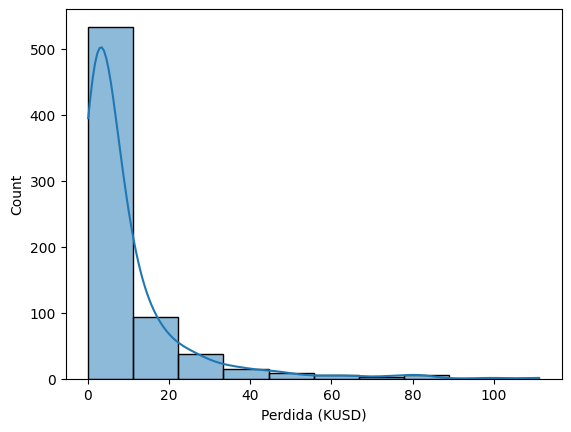

In [7]:
nxl='/content/1. FallasTecnológicas.xlsx'
XDB=pd.read_excel(nxl, sheet_name=0)

LDA = XDB['LDA']

plt.figure()
sns.histplot(LDA,bins=10,kde=True)
plt.xlabel("Perdida (KUSD)")
plt.show()

In [9]:
NI=10
# Eliminamos los valores NaN de LDA antes de calcular el histograma
LDA_cleaned = LDA.dropna()
counts,bin_edges=np.histogram(LDA_cleaned,bins=NI)
print("el Numero de datos por intervalo")
print(counts)
print("Los Intervalos Inferiores:")
print(bin_edges[:-1])
print("el limite superior de cada intervalo")
print(bin_edges[1:])
XC=(bin_edges[:-1]+bin_edges[1:])/2

el Numero de datos por intervalo
[533  93  37  14   9   5   3   5   1   1]
Los Intervalos Inferiores:
[ 0.1423  11.23637 22.33044 33.42451 44.51858 55.61265 66.70672 77.80079
 88.89486 99.98893]
el limite superior de cada intervalo
[ 11.23637  22.33044  33.42451  44.51858  55.61265  66.70672  77.80079
  88.89486  99.98893 111.083  ]


In [10]:
tabla=np.column_stack((bin_edges[:-1],bin_edges[1:],XC,counts))
df=pd.DataFrame(tabla,columns=['LI','LS','XC','ND'])
df.head(10)

,LI,LS,XC,ND
0,0.14230,11.23637,5.689335,533.0
1,11.23637,22.33044,16.783405,93.0
2,22.33044,33.42451,27.877475,37.0
3,33.42451,44.51858,38.971545,14.0
4,44.51858,55.61265,50.065615,9.0
5,55.61265,66.70672,61.159685,5.0
6,66.70672,77.80079,72.253755,3.0
7,77.80079,88.89486,83.347825,5.0
8,88.89486,99.98893,94.441895,1.0
9,99.98893,111.08300,105.535965,1.0


In [11]:
u=np.mean(LDA)
V=np.var(LDA)
sigma=np.std(LDA)

T2=np.column_stack((u,V,sigma))
df2=pd.DataFrame(T2,columns=['Media','Varianza','Desviacion'])
df2.head()

,Media,Varianza,Desviacion
0,9.451113,187.894776,13.707472


In [14]:
from scipy.stats import skew, kurtosis
lda_skew = skew(LDA_cleaned)
lda_kurtosis = kurtosis(LDA_cleaned)
df2_temp = df2.copy()
df2_temp['Asimetria'] = lda_skew
df2_temp['Curtosis'] = lda_kurtosis
display(df2_temp)

,Media,Varianza,Desviacion,Asimetria,Curtosis
0,9.451113,187.894776,13.707472,3.34836,14.167714


In [16]:
# Cálculo de parámetros de riesgo

#Media de las pérdidas
expected_loss = u

#Desviación estándar de las pérdidas
unexpected_loss = sigma

# Pérdidas Catastróficas (PC) - Percentil 99 de las pérdidas
catastrophic_loss = np.percentile(LDA_cleaned, 99)


if 'df2_temp' not in locals() or df2_temp is None:
    df2_temp = pd.DataFrame([[u, V, sigma, lda_skew, lda_kurtosis]], columns=['Media', 'Varianza', 'Desviacion', 'Asimetria', 'Curtosis'])

df2_temp['Perdida_Esperada'] = expected_loss
df2_temp['Perdida_No_Esperada'] = unexpected_loss
df2_temp['Perdida_Catastrofica'] = catastrophic_loss

display(df2_temp)

,Media,Varianza,Desviacion,Asimetria,Curtosis,Perdida_Esperada,Perdida_No_Esperada,Perdida_Catastrofica
0,9.451113,187.894776,13.707472,3.34836,14.167714,9.451113,13.707472,74.3883


In [25]:
df2_temp['Num_Total_Eventos'] = num_total_events
df2_temp['Periodo_Dias'] = time_period_days
df2_temp['Lambda_Poisson'] = lambda_param
display(df2_temp)

,Media,Varianza,Desviacion,Asimetria,Curtosis,Perdida_Esperada,Perdida_No_Esperada,Perdida_Catastrofica,Num_Total_Eventos,Periodo_Dias,Lambda_Poisson,VaR_99.9
0,9.451113,187.894776,13.707472,3.34836,14.167714,9.451113,13.707472,74.3883,701,1080,0.649074,188.074769


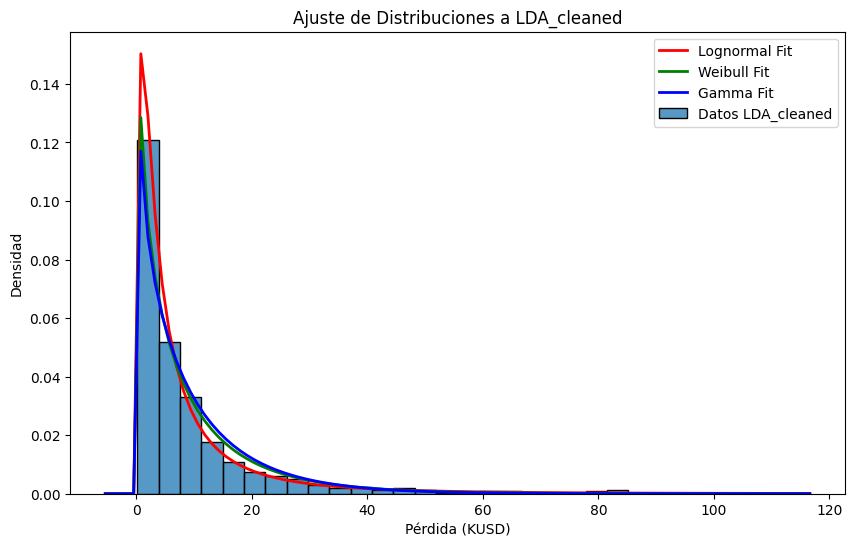

In [26]:
plt.figure(figsize=(10, 6))
sns.histplot(LDA_cleaned, bins=30, kde=False, stat='density', label='Datos LDA_cleaned')

# Plot Lognormal PDF
xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 100)
p_lognorm = lognorm.pdf(x, *params_lognorm)
plt.plot(x, p_lognorm, 'r-', lw=2, label='Lognormal Fit')

# Plot Weibull_min PDF
p_weibull = weibull_min.pdf(x, *params_weibull)
plt.plot(x, p_weibull, 'g-', lw=2, label='Weibull Fit')

# Plot Gamma PDF
p_gamma = gamma.pdf(x, *params_gamma)
plt.plot(x, p_gamma, 'b-', lw=2, label='Gamma Fit')

plt.title('Ajuste de Distribuciones a LDA_cleaned')
plt.xlabel('Pérdida (KUSD)')
plt.ylabel('Densidad')
plt.legend()
plt.show()


## Interpretación

### 1. Contexto y Objetivo
El objetivo de este análisis ha sido cuantificar el riesgo operacional asociado a las "Fallas Tecnológicas


**Interpretación**: Se estima que, en promedio, ocurren aproximadamente 0.65 fallas tecnológicas por día. Esto implica que las fallas no son un evento diario, sino que ocurren de forma intermitente, con aproximadamente 237 fallas por año (0.649 * 365 días).

*


*   **Media (Pérdida Esperada)**: 9.45 KUSD
    *   **Análisis**: Este es el costo promedio de una falla tecnológica. La empresa puede esperar, en promedio, una pérdida de 9.45 KUSD por evento.


*   **Desviación Estándar (Pérdida No Esperada)**: 13.71 KUSD
    *   **Análisis**: Representa la incertidumbre o volatilidad de las pérdidas. Es una medida clave de cuánto pueden desviarse las pérdidas reales del promedio esperado. Un valor de 13.71 KUSD es relativamente alto comparado con la pérdida esperada, indicando un grado significativo de riesgo.

*   **Asimetría**: 3.35
    *   **Análisis**: El valor positivo y alto confirma el sesgo a la derecha de la distribución de severidad. La mayoría de las fallas son de bajo costo, pero hay una 'cola larga' de eventos de alto costo que impactan significativamente el promedio y la variabilidad.

*   **Curtosis**: 14.17
    *   **Análisis**: El valor alto. Esto significa que la distribución de pérdidas tiene un pico más pronunciado. En la práctica, esto implica una mayor probabilidad de eventos de pérdida extremos (tanto muy pequeños como muy grandes) de lo que una distribución normal predeciría, lo cual es coherente con la asimetría observada.

